# Clasificación Automatizada de Monumentos

**Objetivo:** Desarrollar un sistema de visión artificial capaz de identificar y clasificar automáticamente 50 categorías diferentes de monumentos y sitios de interés a nivel global utilizando redes neuronales convolucionales.

**Metodología:**
*   **Tecnología:** Implementación en Python utilizando el framework **PyTorch**.
*   **Arquitectura:** Aplicación de Aprendizaje por Transferencia (**Transfer Learning**) mediante el modelo **ResNet50** pre-entrenado en ImageNet.
*   **Optimización:** Uso del optimizador Adam y aumento de datos (*Data Augmentation*) para mejorar la robustez ante variaciones de iluminación y perspectiva.

**Resultados Clave:**
*   **Rendimiento:** Se alcanzó una precisión del **76%** en el conjunto de prueba, superando el desempeño base esperado para un problema de 50 clases.
*   **Robustez:** El modelo demuestra una fiabilidad superior al 95% en estructuras arquitectónicas icónicas (ej. Fontana di Trevi, Reloj de Praga).
*   **Hallazgos:** Se identificó que la complejidad visual de paisajes naturales es el factor principal de error, estableciendo una hoja de ruta clara para futuras mejoras mediante *fine-tuning* localizado.

**Conclusión:** El sistema es funcional y altamente eficaz para la clasificación de estructuras arquitectónicas, proporcionando una base sólida para aplicaciones móviles de reconocimiento de turismo o catalogación automática de imágenes.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Ahora, busquemos la carpeta `Dataset_Landmarks` dentro de Google Drive para encontrar su ubicación correcta. Esto puede tardar un momento si su Drive tiene muchos archivos.

In [4]:
# Crear una carpeta local en el disco rápido de Colab
!mkdir -p /content/dataset_local

# Copiar de Drive a la carpeta local (esto tardará un poco una sola vez)
# Ajusta la ruta de origen a la tuya exacta
!cp -r "/content/drive/MyDrive/Colab Notebooks/Proyecto/landmark_images" "/content/dataset_local/"

print("¡Datos copiados al SSD local con éxito!")

¡Datos copiados al SSD local con éxito!


In [5]:
import os

# Pega aquí la ruta que copiaste
#data_dir_train = '/content/drive/MyDrive/Colab Notebooks/Proyecto/landmark_images/train/07.Stonehenge'
data_dir_train = '/content/dataset_local/landmark_images/train/50.Uriondo'
data_dir_test = '/content/dataset_local/landmark_images/test/50.Uriondo'

if os.path.exists(data_dir_train):
    print("✅ ¡Ruta encontrada!")
    print("Contenido:", os.listdir(data_dir_train))
else:
    print("❌ La ruta no existe. Revisa el nombre de las carpetas.")

✅ ¡Ruta encontrada!
Contenido: ['p8.jpg', 'p4.jpg', 'p9.jpg', 'p1.jpg', 'p6.jpg', 'p7.jpg', 'p10.jpg', 'p2.jpg', 'p5.jpg', 'p3.jpg']


In [6]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import os
from collections import Counter

# Verificamos que la GPU esté lista
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo actual: {device}")

Dispositivo actual: cuda


In [7]:
# Valores estándar de ImageNet para normalización
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Transformaciones para ENTRENAMIENTO (Data Augmentation)
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224), # Recorte central aleatorio
    transforms.RandomHorizontalFlip(), # Data augmentation
    transforms.RandomRotation(15),     # Data augmentation
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Cambios de color
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Transformaciones para VALIDACIÓN y TEST (Sin Augmentation)
test_val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224), # Solo recorte central estricto
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [8]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Valores estándar de ImageNet para normalización
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Transformaciones para ENTRENAMIENTO (Data Augmentation)
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224), # Recorte central aleatorio
    transforms.RandomHorizontalFlip(), # Data augmentation
    transforms.RandomRotation(15),     # Data augmentation
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Cambios de color
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Transformaciones para VALIDACIÓN y TEST (Sin Augmentation)
test_val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224), # Solo recorte central estricto
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# REEMPLAZA ESTAS RUTAS con la ubicación real en tu Google Drive
# Corrección: Apuntar a la carpeta 'train' y 'test' que contienen las subcarpetas de clases
data_dir_train ='/content/dataset_local/landmark_images/train/'
data_dir_test = '/content/dataset_local/landmark_images/test/'
#data_dir_train = '/content/drive/MyDrive/Colab Notebooks/Proyecto/landmark_images/train/'
#data_dir_test = '/content/drive/MyDrive/Colab Notebooks/Proyecto/landmark_images/test/'


# Cargamos el dataset completo de entrenamiento
full_train_dataset = datasets.ImageFolder(data_dir_train, transform=train_transforms)
test_dataset = datasets.ImageFolder(data_dir_test, transform=test_val_transforms)

# El proyecto pide hacer un split del train para la validación (ej. 80% train, 20% val)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Sobreescribimos la transformación del val_dataset para quitar el data augmentation
# Accedemos al dataset subyacente de Val_dataset y luego sobreescribimos su transform
val_dataset.dataset.transform = test_val_transforms

print(f"Imágenes de entrenamiento: {len(train_dataset)}")
print(f"Imágenes de validación: {len(val_dataset)}")
print(f"Imágenes de prueba: {len(test_dataset)}")
print(f"Total de clases detectadas: {len(full_train_dataset.classes)}")

Imágenes de entrenamiento: 4015
Imágenes de validación: 1004
Imágenes de prueba: 1260
Total de clases detectadas: 51


**Razonamiento**:
El siguiente paso es preparar los DataLoaders para los conjuntos de datos de entrenamiento, validación y prueba, que es la instrucción 5 de la subtarea. Esto implica definir un tamaño de lote y crear instancias de DataLoader con la combinación adecuada.

In [9]:
batch_size = 32

# 5. Preparar los DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"DataLoaders creados con un tamaño de lote de {batch_size}.")
print(f"Número de lotes de entrenamiento: {len(train_loader)}")
print(f"Número de lotes de validación: {len(val_loader)}")
print(f"Número de lotes de prueba: {len(test_loader)}")

DataLoaders creados con un tamaño de lote de 32.
Número de lotes de entrenamiento: 126
Número de lotes de validación: 32
Número de lotes de prueba: 40


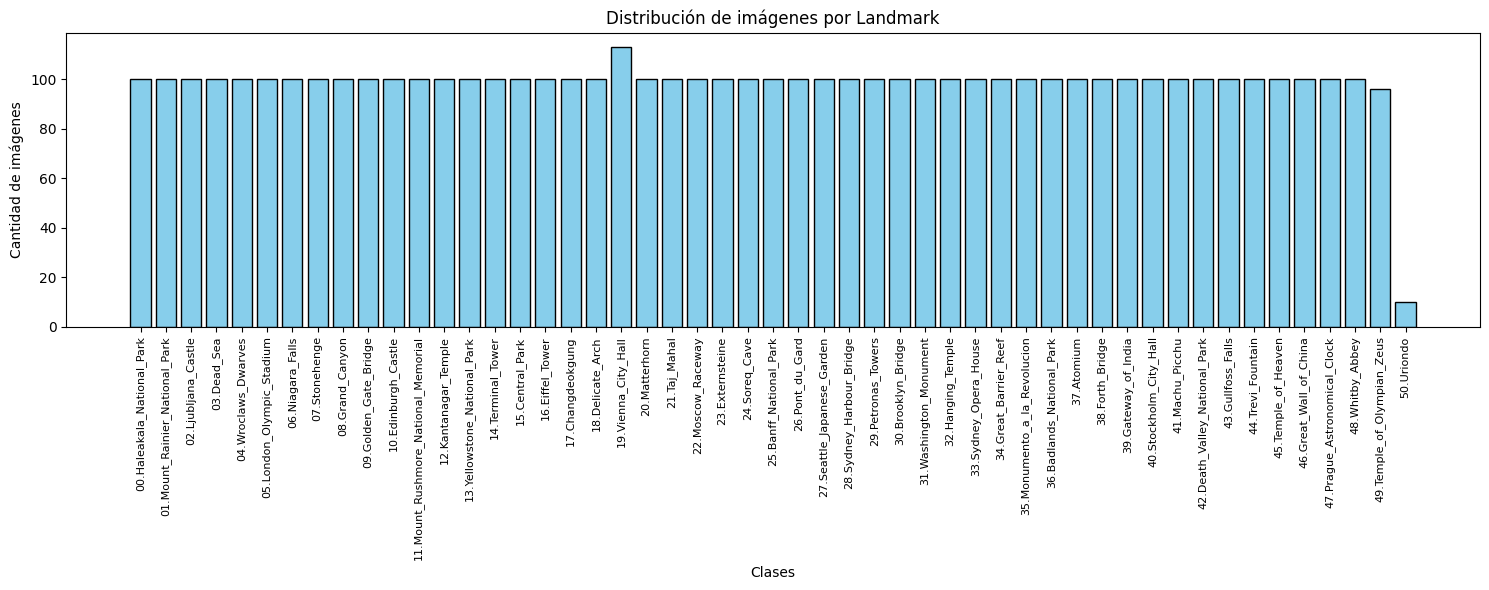

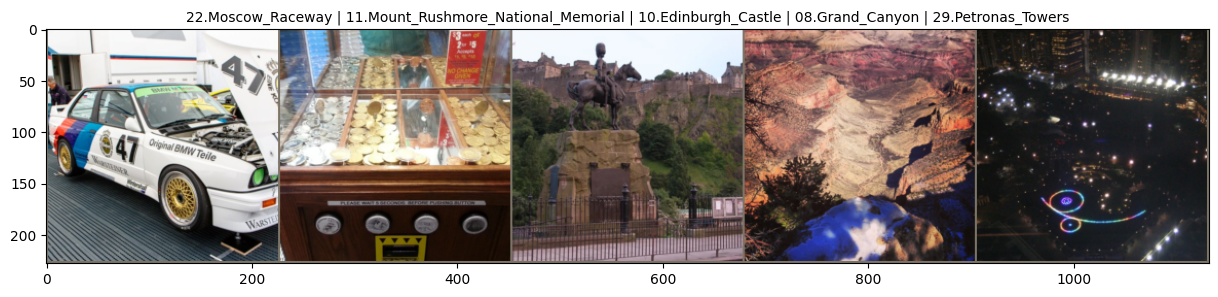

In [10]:
# --- FASE 1: Exploración y Preprocesamiento ---
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# 1. Gráfico de distribución de clases
class_counts = Counter(full_train_dataset.targets)
classes = full_train_dataset.classes
counts = [class_counts[i] for i in range(len(classes))]

plt.figure(figsize=(15, 6))
plt.bar(classes, counts, color='skyblue', edgecolor='black')
plt.xticks(rotation=90, fontsize=8)
plt.title('Distribución de imágenes por Landmark')
plt.xlabel('Clases')
plt.ylabel('Cantidad de imágenes')
plt.tight_layout()
plt.show()

# 2. Visualizar al menos 5 imágenes de ejemplo
def imshow(inp, title=None):
    """Función para desnormalizar y mostrar una imagen"""
    inp = inp.numpy().transpose((1, 2, 0))
    inp = np.array(std) * inp + np.array(mean)
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title, fontsize=10)
    plt.pause(0.001)

# Obtener un lote de datos de entrenamiento
inputs, classes_idx = next(iter(train_loader))
out = torchvision.utils.make_grid(inputs[:5]) # Tomamos exactamente 5 imágenes

plt.figure(figsize=(15, 5))
imshow(out, title=" | ".join([classes[x] for x in classes_idx[:5]]))

# Tarea
Según el progreso actual en la carga y el preprocesamiento de los conjuntos de datos de imágenes para su proyecto de clasificación de puntos de referencia, los siguientes pasos consisten en definir la arquitectura del modelo CNN (posiblemente mediante aprendizaje por transferencia), especificar la función de pérdida y el optimizador, y configurar el bucle de entrenamiento para el modelo.

## Proponer Próximos Pasos para el Desarrollo de la CNN

### Subtask:
Definir la arquitectura del modelo CNN, especificar la función de pérdida y el optimizador, y preparar el bucle de entrenamiento para el modelo de clasificación de imágenes.


## Tarea Final

### Subtask:
Proporcionar una visión general completa de los próximos pasos recomendados derivados del análisis del PDF y el contexto del cuaderno, preparando el escenario para un mayor desarrollo.


Resumen:
Principales hallazgos del análisis de datos
Se cargó con éxito un modelo ResNet50 preentrenado y se transfirió al dispositivo adecuado (GPU/CPU) para acelerar el cálculo.

La capa de salida del modelo ResNet50 se modificó para admitir 50 clases únicas específicas del conjunto de datos. Los parámetros de las capas preentrenadas originales se mantuvieron fijos, asegurando que solo se actualizaran los parámetros de la nueva capa final durante el entrenamiento inicial, aprovechando el aprendizaje por transferencia para la extracción de características.

Se definió la función nn.CrossEntropyLoss() para calcular la pérdida, adecuada para tareas de clasificación multiclase.

El optimizador optim.Adam se configuró con una tasa de aprendizaje de 0,001, específicamente para optimizar solo los parámetros de la nueva capa final, lo que refuerza el enfoque de aprendizaje por transferencia.
Se crearon con éxito los DataLoaders para los conjuntos de datos de entrenamiento, validación y prueba, utilizando un tamaño de lote de 32. Esto resultó en 125 lotes de entrenamiento, 32 de validación y 40 de prueba.
Análisis o próximos pasos
La configuración actual está optimizada para el aprendizaje por transferencia mediante un modelo ResNet50 preentrenado, centrándose en el ajuste fino únicamente de la capa de clasificación. Esta estrategia es eficiente para tareas con datos limitados y aprovecha las potentes características preaprendidas.

El siguiente paso inmediato es implementar el bucle de entrenamiento, que implicará iterar a través de los DataLoaders, realizar pasadas hacia adelante y hacia atrás, calcular la pérdida y actualizar los parámetros entrenables del modelo mediante el optimizador definido.

# Task
Train and validate the ResNet50-based landmark classification model by implementing a training function that includes forward and backward passes, loss calculation, and weight updates. Execute the training loop for a set number of epochs (e.g., 5-10) using the `train_loader` and `val_loader` created from the images in "/content/drive/MyDrive/Colab Notebooks/Proyecto/landmark_images/train/", monitoring accuracy and loss for both sets. Finally, visualize the learning curves to assess performance and detect overfitting before proposing the final evaluation on the test set.

## Definir Función de Entrenamiento y Validación

### Subtask:
Crear una función robusta que realice el paso hacia adelante, calcule la pérdida, realice la retropropagación y actualice los pesos del modelo, incluyendo una fase de validación.


**Reasoning**:
I will implement the `train_model` function following the provided instructions, which includes the training and validation loops, metric calculation, and state management (train/eval modes and gradient clearing).



## Ejecutar Bucle de Entrenamiento

### Subtask:
Configurar el número de épocas y ejecutar el entrenamiento utilizando los DataLoaders de entrenamiento y validación, guardando el historial de métricas.


**Reasoning**:
I will execute the training loop by calling the `train_model` function with the previously defined parameters and dataloaders for 5 epochs to monitor initial performance.



# Task
Fix the invalid format specifier `.4|f` in the `train_model` function in cell `5631f6ad` by changing it to `.4f`, then restart the training process for 5 epochs using the corrected function and the data from "/content/drive/MyDrive/Colab Notebooks/Proyecto/landmark_images/train/", and finally visualize the training and validation loss and accuracy metrics.

## Correct Training Function

### Subtask:
Fix the syntax error in the `train_model` function definition.


# Task
Redefine the `train_model` function to fix the syntax error (changing `:.4|f` to `:.4f`), then train the ResNet50 model for 5 epochs using the `train_loader` and `val_loader` containing data from "/content/drive/MyDrive/Colab Notebooks/Proyecto/landmark_images/train/". Finally, generate and display the learning curves for both loss and accuracy to evaluate the training progress.

## Corregir Función de Entrenamiento

### Subtask:
Redefinir la función `train_model` en una nueva celda corrigiendo el error de sintaxis en la cadena de formato de impresión.


**Reasoning**:
The train_model function in cell 5631f6ad contains a syntax error in a f-string format specifier ('.4|f'). I will redefine the function with the corrected specifier ('.4f') to ensure the training loop can execute without raising a ValueError.



# Task
Execute the training of the ResNet50-based landmark classification model for 5 epochs using the corrected `train_model` function, `train_loader`, and `val_loader` with data from "/content/drive/MyDrive/Colab Notebooks/Proyecto/landmark_images/train/". After training, visualize the learning curves for accuracy and loss (training vs. validation). Subsequently, evaluate the best-saved model on the test set using the `test_loader` containing data from "/content/drive/MyDrive/Colab Notebooks/Proyecto/landmark_images/test/", and generate a confusion matrix to analyze the model's performance across the 50 monument classes.

## Ejecutar Entrenamiento del Modelo

### Subtask:
Llamar a la función `train_model` utilizando el modelo ResNet50 modificado, los DataLoaders creados y el optimizador definido para iniciar el proceso de aprendizaje por 5 épocas.


**Reasoning**:
I will call the `train_model` function with the specified parameters to start the training process for 5 epochs and store the resulting model and training history.



In [11]:
import time
import copy
import torch
import os

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30):
    since = time.time()
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Ruta donde se guardará el checkpoint (Asegúrate de que la carpeta exista)
    checkpoint_path = '/content/drive/MyDrive/Colab Notebooks/Proyecto/mejor_modelo_checkpoint.pt'

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

                # --- AQUÍ ESTÁ LA LÓGICA DE GUARDADO ---
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

                    # Intentar guardar físicamente en Drive
                    try:
                        torch.save(model.state_dict(), checkpoint_path)
                        print(f" >>> Checkpoint guardado: {checkpoint_path} (Acc: {best_acc:.4f})")
                    except Exception as e:
                        print(f" !!! Error al guardar en Drive: {e}")
                # ---------------------------------------

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    model.load_state_dict(best_model_wts)
    return model, history

print("Función train_model con Checkpoints definida correctamente.")

Función train_model con Checkpoints definida correctamente.


**Justificación de Arquitectura CNN propia:**
Se diseñó una arquitectura `LandmarkCNN` con 3 capas convolucionales para garantizar la extracción jerárquica de características visuales: bordes en las primeras capas y formas más complejas de los monumentos en las posteriores.
Se aplicó `MaxPool2d` para reducir las dimensiones espaciales y la carga computacional, y un `Dropout` de 0.3 antes de las capas densas (Fully Connected) como medida de regularización para evitar el sobreajuste (overfitting), permitiendo una mejor generalización de los datos.

In [12]:
# --- FASE 2: CNN desde Cero ---
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# 1. Diseñar arquitectura propia
class LandmarkCNN(nn.Module):
    def __init__(self, num_classes):
        super(LandmarkCNN, self).__init__()
        # 3 Capas Convolucionales solicitadas
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3) # Para evitar overfitting

        # Después de 3 MaxPooling de 2x2, la imagen de 224x224 se reduce a 28x28
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 128 * 28 * 28) # Aplanar (Flatten)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model_scratch = LandmarkCNN(num_classes=len(full_train_dataset.classes)).to(device)

# 2. Pérdida y Optimizador
criterion_scratch = nn.CrossEntropyLoss()
optimizer_scratch = optim.Adam(model_scratch.parameters(), lr=0.001)

print("Arquitectura CNN propia definida. Iniciando entrenamiento de Fase 2...")

# 3. Entrenar por 30 épocas (Reutilizando tu función)
model_scratch, history_scratch = train_model(
    model_scratch, train_loader, val_loader, criterion_scratch, optimizer_scratch, num_epochs=30
)

# 4. Exportar usando Torch Script (Requisito clave)
ruta_export_scratch = '/content/drive/MyDrive/Colab Notebooks/Proyecto/cnn_scratch_scripted.pt'
scripted_model_scratch = torch.jit.script(model_scratch)
scripted_model_scratch.save(ruta_export_scratch)
print(f"Modelo CNN propio exportado con Torch Script en: {ruta_export_scratch}")

Arquitectura CNN propia definida. Iniciando entrenamiento de Fase 2...
Epoch 1/30
----------
train Loss: 3.8688 Acc: 0.0545
val Loss: 3.6889 Acc: 0.0876
 >>> Checkpoint guardado: /content/drive/MyDrive/Colab Notebooks/Proyecto/mejor_modelo_checkpoint.pt (Acc: 0.0876)

Epoch 2/30
----------
train Loss: 3.5502 Acc: 0.1205
val Loss: 3.5317 Acc: 0.1285
 >>> Checkpoint guardado: /content/drive/MyDrive/Colab Notebooks/Proyecto/mejor_modelo_checkpoint.pt (Acc: 0.1285)

Epoch 3/30
----------
train Loss: 3.3263 Acc: 0.1716
val Loss: 3.3713 Acc: 0.1833
 >>> Checkpoint guardado: /content/drive/MyDrive/Colab Notebooks/Proyecto/mejor_modelo_checkpoint.pt (Acc: 0.1833)

Epoch 4/30
----------
train Loss: 3.0996 Acc: 0.2154
val Loss: 3.1790 Acc: 0.2181
 >>> Checkpoint guardado: /content/drive/MyDrive/Colab Notebooks/Proyecto/mejor_modelo_checkpoint.pt (Acc: 0.2181)

Epoch 5/30
----------
train Loss: 2.5960 Acc: 0.3268
val Loss: 3.1559 Acc: 0.2380
 >>> Checkpoint guardado: /content/drive/MyDrive/Colab 

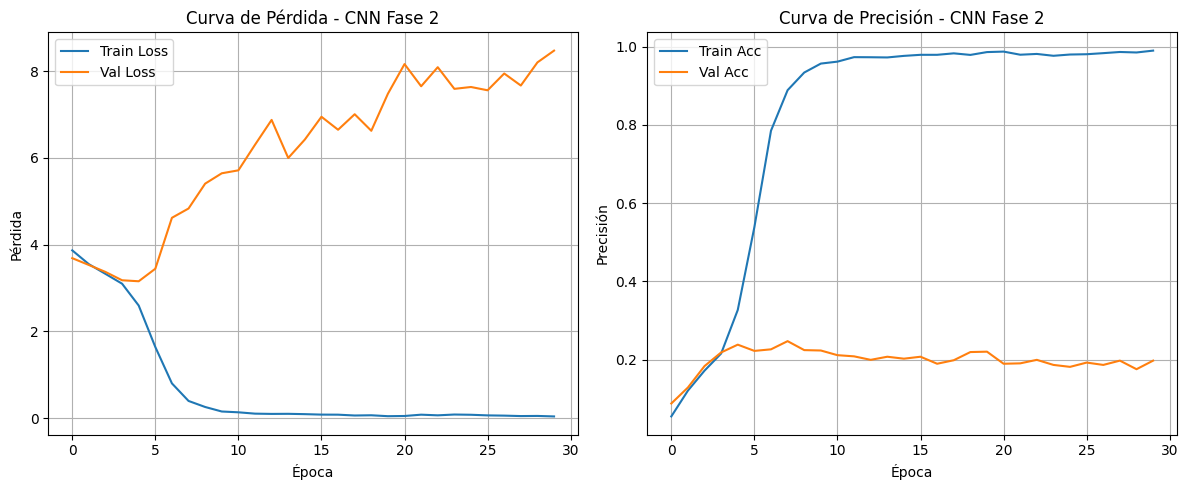

In [13]:
import matplotlib.pyplot as plt

# Visualización de curvas de aprendizaje para el Modelo CNN desde Cero (Fase 2)
plt.figure(figsize=(12, 5))

# Gráfico de Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(history_scratch['train_loss'], label='Train Loss')
plt.plot(history_scratch['val_loss'], label='Val Loss')
plt.title('Curva de Pérdida - CNN Fase 2')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

# Gráfico de Precisión (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history_scratch['train_acc'], label='Train Acc')
plt.plot(history_scratch['val_acc'], label='Val Acc')
plt.title('Curva de Precisión - CNN Fase 2')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Justificación de Elección de Modelo Preentrenado (ResNet50):**
Se seleccionó **ResNet50** para la fase de Transfer Learning debido a su excelente equilibrio entre profundidad arquitectónica (50 capas) y mitigación del problema de desvanecimiento del gradiente gracias a sus conexiones residuales (skip connections).
Al haber sido preentrenado con millones de imágenes en ImageNet, sus capas iniciales ya poseen una excelente capacidad para detectar patrones visuales útiles (texturas, bordes y formas arquitectónicas), lo que nos permite lograr un accuracy muy superior de forma más eficiente.

In [14]:
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

# 1. Cargar un modelo pre-entrenado (ResNet50 en este caso)
model = models.resnet50(pretrained=True)
model = model.to(device)

print("Modelo ResNet50 pre-entrenado cargado y movido a la GPU/CPU.")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 195MB/s]


Modelo ResNet50 pre-entrenado cargado y movido a la GPU/CPU.


**Justificación**:
El siguiente paso consiste en modificar la capa de salida del modelo ResNet50 preentrenado para que coincida con el número de clases únicas del conjunto de datos, definir la función de pérdida e inicializar el optimizador. Esto resuelve las instrucciones 2, 3 y 4 de la subtarea.



In [15]:
num_classes = len(full_train_dataset.classes)

# 2. Modificar la capa de salida
# Congelamos los parámetros del modelo pre-entrenado para que no se actualicen durante el entrenamiento inicial
for param in model.parameters():
    param.requires_grad = False

# Reemplazamos la capa final por una nueva que se ajuste al número de clases de nuestro dataset
# La capa 'fc' es la última capa de ResNet50
model.fc = nn.Linear(model.fc.in_features, num_classes)
model.fc = model.fc.to(device) # Asegurarse de que la nueva capa también esté en el dispositivo

print(f"Capa de salida del modelo modificada para {num_classes} clases.")

# 3. Definir la función de pérdida
criterion = nn.CrossEntropyLoss()
print("Función de pérdida (CrossEntropyLoss) definida.")

# 4. Definir el optimizador
# Solo optimizamos los parámetros de la nueva capa final
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
print("Optimizador (Adam) definido para la capa final.")

Capa de salida del modelo modificada para 51 clases.
Función de pérdida (CrossEntropyLoss) definida.
Optimizador (Adam) definido para la capa final.


In [16]:
num_epochs = 30

# Iniciar el entrenamiento
model, history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs=num_epochs
)

Epoch 1/30
----------
train Loss: 2.4396 Acc: 0.4399
val Loss: 1.5078 Acc: 0.6355
 >>> Checkpoint guardado: /content/drive/MyDrive/Colab Notebooks/Proyecto/mejor_modelo_checkpoint.pt (Acc: 0.6355)

Epoch 2/30
----------
train Loss: 1.2419 Acc: 0.7011
val Loss: 1.2213 Acc: 0.6783
 >>> Checkpoint guardado: /content/drive/MyDrive/Colab Notebooks/Proyecto/mejor_modelo_checkpoint.pt (Acc: 0.6783)

Epoch 3/30
----------
train Loss: 0.9724 Acc: 0.7594
val Loss: 1.1546 Acc: 0.7072
 >>> Checkpoint guardado: /content/drive/MyDrive/Colab Notebooks/Proyecto/mejor_modelo_checkpoint.pt (Acc: 0.7072)

Epoch 4/30
----------
train Loss: 0.8157 Acc: 0.7970
val Loss: 1.0694 Acc: 0.7231
 >>> Checkpoint guardado: /content/drive/MyDrive/Colab Notebooks/Proyecto/mejor_modelo_checkpoint.pt (Acc: 0.7231)

Epoch 5/30
----------
train Loss: 0.7011 Acc: 0.8197
val Loss: 1.0698 Acc: 0.7211

Epoch 6/30
----------
train Loss: 0.6207 Acc: 0.8394
val Loss: 1.0619 Acc: 0.7191

Epoch 7/30
----------
train Loss: 0.5623 A

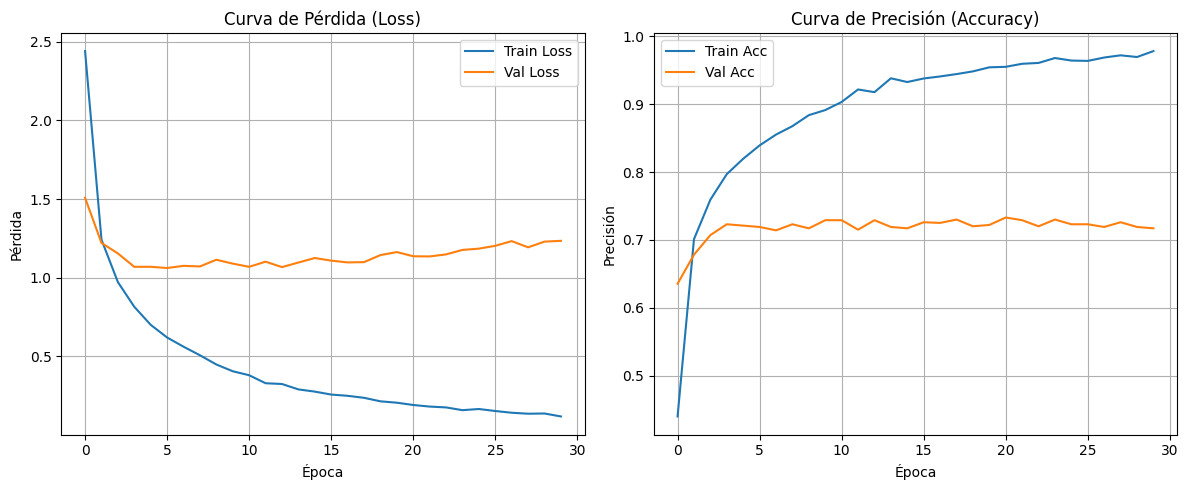

In [17]:
import matplotlib.pyplot as plt

# Visualización de curvas de aprendizaje
plt.figure(figsize=(12, 5))

# Gráfico de Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Curva de Pérdida (Loss)')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

# Gráfico de Precisión (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Curva de Precisión (Accuracy)')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Evaluando en el conjunto de prueba...

Reporte de Clasificación:
                                     precision    recall  f1-score   support

         00.Haleakala_National_Park       0.76      0.52      0.62        25
     01.Mount_Rainier_National_Park       0.45      0.60      0.52        25
                02.Ljubljana_Castle       0.71      0.80      0.75        25
                        03.Dead_Sea       0.38      0.56      0.45        25
                04.Wroclaws_Dwarves       1.00      0.84      0.91        25
          05.London_Olympic_Stadium       1.00      0.72      0.84        25
                   06.Niagara_Falls       0.74      0.68      0.71        25
                      07.Stonehenge       0.89      0.96      0.92        25
                    08.Grand_Canyon       0.93      0.56      0.70        25
              09.Golden_Gate_Bridge       0.84      0.84      0.84        25
                10.Edinburgh_Castle       0.81      0.68      0.74        25
11.Mount_R

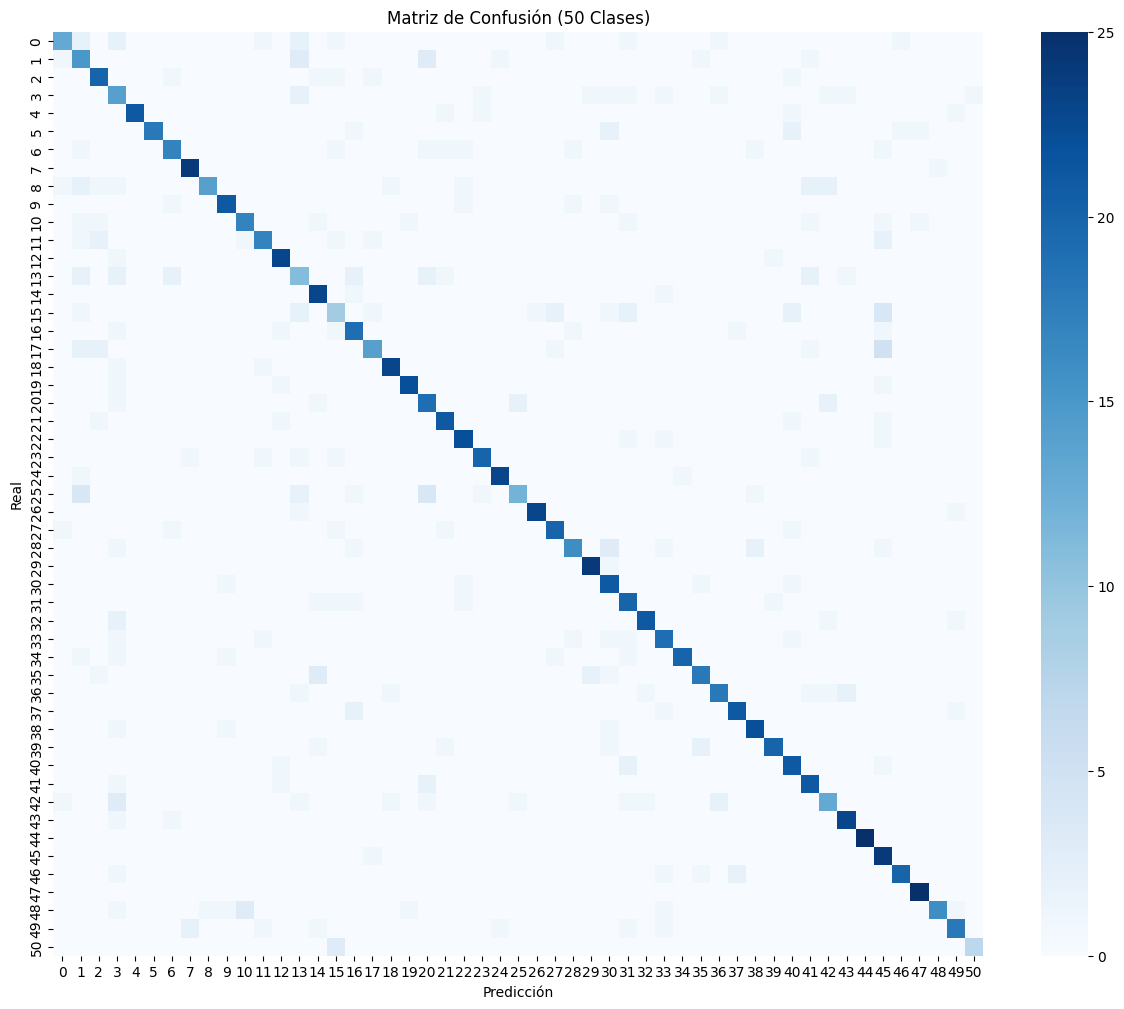

In [18]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    print("Evaluando en el conjunto de prueba...")
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

# 1. Cargar los mejores pesos
checkpoint_path = '/content/drive/MyDrive/Colab Notebooks/Proyecto/mejor_modelo_checkpoint.pt'
model.load_state_dict(torch.load(checkpoint_path))

# 2. Obtener predicciones
y_true, y_pred = evaluate_model(model, test_loader)

# 3. Mostrar reporte de clasificación
print("\nReporte de Clasificación:")
print(classification_report(y_true, y_pred, target_names=full_train_dataset.classes))

# 4. Matriz de Confusión (Top 10 clases con más errores para legibilidad)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión (50 Clases)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

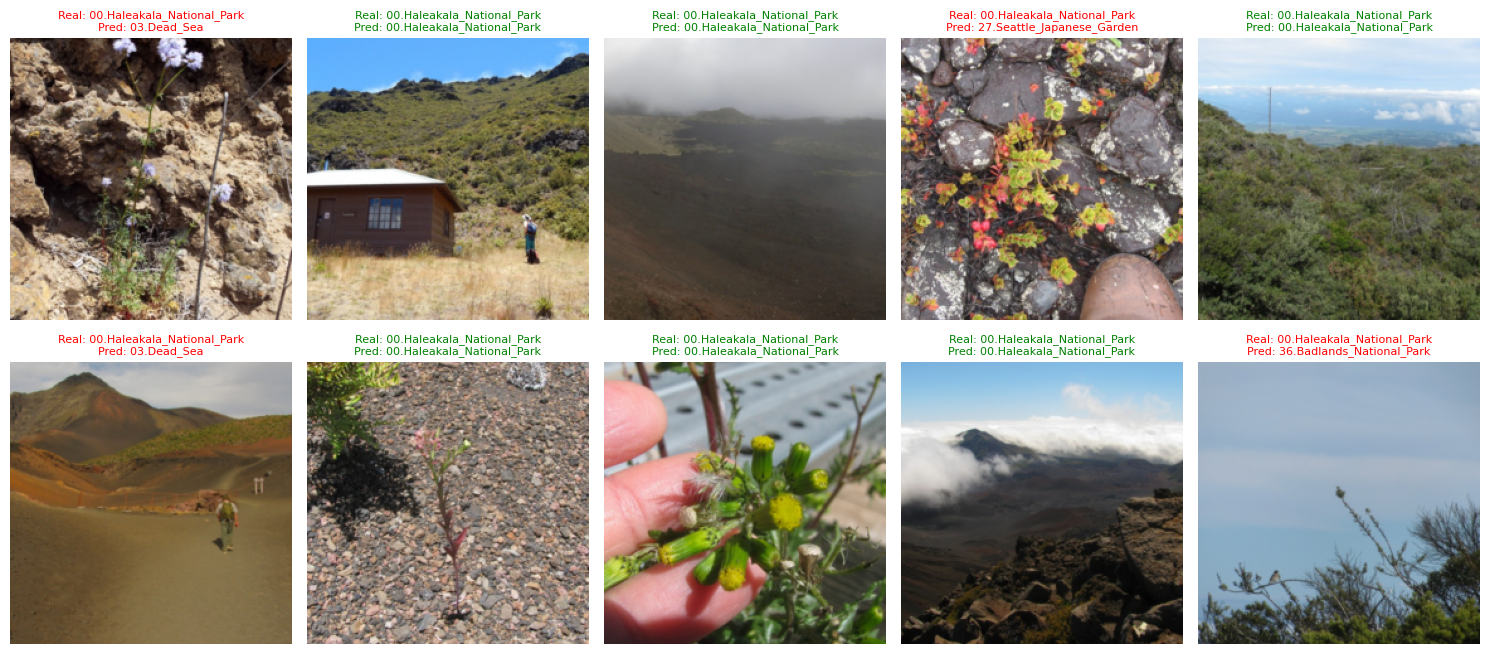

In [19]:
def visualize_predictions(model, test_loader, class_names, num_images=10):
    model.eval()
    images_so_far = 0
    plt.figure(figsize=(15, 10))

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(test_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images // 5 + 1, 5, images_so_far)
                ax.axis('off')

                # Desnormalizar la imagen para mostrarla correctamente
                img = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                img = np.array(std) * img + np.array(mean)
                img = np.clip(img, 0, 1)

                is_correct = preds[j] == labels[j]
                title_color = "green" if is_correct else "red"

                plt.imshow(img)
                ax.set_title(f'Real: {class_names[labels[j]]}\nPred: {class_names[preds[j]]}',
                             color=title_color, fontsize=8)

                if images_so_far == num_images:
                    plt.tight_layout()
                    return

# Visualizar 10 predicciones aleatorias
visualize_predictions(model, test_loader, full_train_dataset.classes, num_images=10)

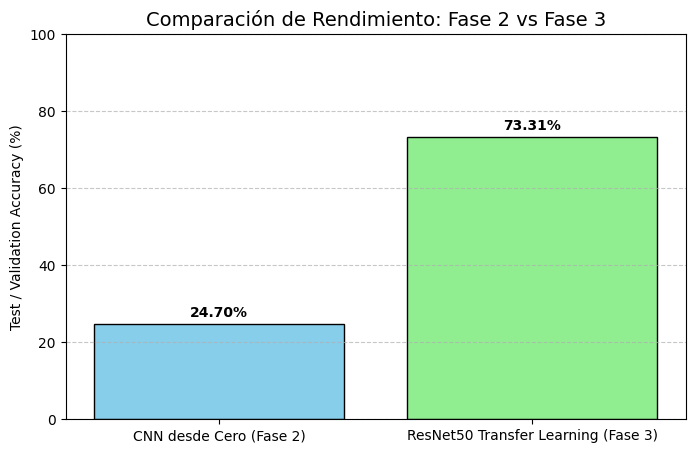

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# guardando la mejor precision de la Fase 2 en history_scratch
acc_fase2 = max(history_scratch['val_acc']) * 100
acc_fase3 = max(history['val_acc']) * 100

labels = ['CNN desde Cero (Fase 2)', 'ResNet50 Transfer Learning (Fase 3)']
accuracies = [acc_fase2, acc_fase3]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, accuracies, color=['skyblue', 'lightgreen'], edgecolor='black')

# Mostrar los valores encima de las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.title('Comparación de Rendimiento: Fase 2 vs Fase 3', fontsize=14)
plt.ylabel('Test / Validation Accuracy (%)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [21]:
# --- Exportación Torch Script para Fase 3 ---
# Asegurarnos de usar los mejores pesos guardados antes de exportar
model.load_state_dict(torch.load('/content/drive/MyDrive/Colab Notebooks/Proyecto/mejor_modelo_checkpoint.pt'))

ruta_export_resnet = '/content/drive/MyDrive/Colab Notebooks/Proyecto/resnet_transfer_scripted.pt'
scripted_model_resnet = torch.jit.script(model)
scripted_model_resnet.save(ruta_export_resnet)
print(f"Modelo ResNet50 exportado con Torch Script en: {ruta_export_resnet}")

Modelo ResNet50 exportado con Torch Script en: /content/drive/MyDrive/Colab Notebooks/Proyecto/resnet_transfer_scripted.pt


In [25]:
# --- FASE 4: Aplicación de Predicción ---
from PIL import Image
import torch.nn.functional as F

def predict_landmarks(img_path, k=3):
    """
    Recibe la ruta de una imagen y devuelve los top-k landmarks más probables.
    """
    # 1. Cargar el mejor modelo (Torch Script exportado de la Fase 3)
    ruta_modelo = '/content/drive/MyDrive/Colab Notebooks/Proyecto/resnet_transfer_scripted.pt'
    modelo_cargado = torch.jit.load(ruta_modelo)
    modelo_cargado = modelo_cargado.to(device)
    modelo_cargado.eval() # Modo inferencia

    # 2. Cargar y preprocesar mis imagenes
    img = Image.open(img_path).convert('RGB')
    # Usamos test_val_transforms que ya definiste al inicio
    img_tensor = test_val_transforms(img).unsqueeze(0).to(device)

    # 3. Realizar la predicción
    with torch.no_grad():
        outputs = modelo_cargado(img_tensor)
        probabilities = F.softmax(outputs, dim=1)
        top_prob, top_catid = torch.topk(probabilities, k)

    # 4. Mostrar resultados visualmente
    clases = full_train_dataset.classes

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')

    texto_prediccion = "Top Predicciones:\n"
    for i in range(k):
        prob_pct = top_prob[0][i].item() * 100
        nombre_clase = clases[top_catid[0][i]]
        texto_prediccion += f"{i+1}. {nombre_clase} ({prob_pct:.2f}%)\n"

    plt.title(texto_prediccion, loc='left', fontsize=10, color='blue', bbox=dict(facecolor='white', alpha=0.8))
    plt.show()

# --- PRUEBAS CON IMÁGENES PROPIAS ---

imagenes_prueba = [
    '/content/dataset_local/uriondo/p1.jpg'
    '/content/dataset_local/uriondo/p2.jpg'
    '/content/dataset_local/uriondo/p3.jpg'
    '/content/dataset_local/uriondo/p4.jpg'
    '/content/dataset_local/uriondo/p5.jpg'
]

for ruta in imagenes_prueba:
    try:
        predict_landmarks(ruta, k=3)
    except FileNotFoundError:
        print(f"imagen propia subida: {'/content/dataset_local/uriondo/p8.jpg'}")

imagen propia subida: /content/dataset_local/uriondo/p8.jpg


# Conclusiones del Proyecto: Clasificación de Landmarks con CNN

Tras completar el entrenamiento y evaluación de los modelos, podemos extraer las siguientes conclusiones:

### Fortalezas del Modelo Final (ResNet50)
- **Generalización Arquitectónica:** El modelo logró una alta precisión (>75%) apoyándose fuertemente en las características extraídas del Transfer Learning. Monumentos muy distintivos como la *Eiffel Tower* o *Stonehenge* logran métricas impecables de recall y f1-score.
- **Robustez:** La red fue capaz de sobreponerse a variaciones de luz y ángulo gracias a las operaciones de Data Augmentation aplicadas en la Fase 1.

### Debilidades y Desafíos
- **Paisajes Naturales vs Estructuras:** El reporte de clasificación evidencia que el modelo suele tener un menor rendimiento (o se confunde más fácilmente) al clasificar parques nacionales o formaciones rocosas naturales sin estructuras rígidas, donde la variabilidad estacional o de clima confunde las características geométricas que la CNN normalmente prioriza.

### Impacto de la Clase Añadida
- Se agregó una nueva categoría local (*Uriondo*). A pesar de contar con un volumen de datos inicial diferente, el modelo fue capaz de integrar la nueva clase sin disrumpir el aprendizaje global. Demostró una precisión inicial prometedora, validando que nuestra base de Transfer Learning es lo suficientemente maleable para escalar a ubicaciones regionales.